# MODEL BASELINE

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import os

# Thiết lập đường dẫn
current_dir = os.getcwd()
base_dir = os.path.dirname(current_dir)
train_path = os.path.join(base_dir, 'data', 'preprocessed', 'train_data.csv')
test_path = os.path.join(base_dir, 'data', 'preprocessed', 'test_data.csv')

# Load dữ liệu đã chia sẵn
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Đã load tập Train: {train_df.shape}")
print(f"Đã load tập Test: {test_df.shape}")

Đã load tập Train: (7292, 14)
Đã load tập Test: (1824, 14)


## 1. Định nghĩa Mô hình Baseline (Mô hình tham chiếu)

Nhóm thống nhất chọn mô hình **Hồi quy tuyến tính đa biến** làm Baseline với các đặc điểm sau:
* **Các biến dự báo (X):** `dien_tich_dat`, `phong_ngu`, `phong_tam`, `so_tang` (Dữ liệu gốc mô tả cấu trúc vật lý cơ bản của một căn nhà).
* **Biến mục tiêu (y):** `gia` (Đơn vị: Tỷ VNĐ).

**Mục tiêu:** Thiết lập một mốc hiệu suất tham chiếu dựa trên các đặc trưng cơ bản và tự nhiên nhất cấu thành nên giá trị của một bất động sản (diện tích và số lượng phòng/tầng). Các mô hình cải tiến của thành viên phía sau phải vượt qua được kết quả của mô hình này.

In [24]:
# 1. Tách X, y từ tập Train và Test
# Lưu ý: X cần ở dạng DataFrame (2D array) nên dùng [['column_name']]
features = ['dien_tich_dat', 'phong_ngu', 'phong_tam', 'so_tang']

X_train = train_df[features]
y_train = train_df['gia']

X_test = test_df[features]
y_test = test_df['gia']

# 2. Khởi tạo và Huấn luyện mô hình Linear Regression (OLS)
model_baseline = LinearRegression()
model_baseline.fit(X_train, y_train)

print("Huấn luyện mô hình Baseline thành công!")
print(f"Hệ số chặn (Intercept): {model_baseline.intercept_:.4f}")

print("Các hệ số góc (Coefficients):")
for feature, coef in zip(features, model_baseline.coef_):
    print(f"  - {feature}: {coef:.4f}")


equation = f"Giá dự đoán (Tỷ VNĐ) = {model_baseline.intercept_:.4f} "
for feature, coef in zip(features, model_baseline.coef_):
    if coef >= 0:
        equation += f"+ {coef:.4f}*{feature} "
    else:
        # Nếu hệ số âm, tự động hiển thị dấu trừ
        equation += f"- {abs(coef):.4f}*{feature} "
        
print("\n--- PHƯƠNG TRÌNH HỒI QUY ---")
print(equation)

Huấn luyện mô hình Baseline thành công!
Hệ số chặn (Intercept): -11.1943
Các hệ số góc (Coefficients):
  - dien_tich_dat: 0.1751
  - phong_ngu: -0.6064
  - phong_tam: 0.6940
  - so_tang: 2.8089

--- PHƯƠNG TRÌNH HỒI QUY ---
Giá dự đoán (Tỷ VNĐ) = -11.1943 + 0.1751*dien_tich_dat - 0.6064*phong_ngu + 0.6940*phong_tam + 2.8089*so_tang 


## 2. Dự đoán và đánh giá hiệu suất

In [25]:
# 1. Dự báo trên tập Test
y_pred = model_baseline.predict(X_test)

# 2. Tính toán các chỉ số đánh giá
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# 3. Hiển thị kết quả (Dùng cho bảng so sánh trong báo cáo)
results = pd.DataFrame({
    'Metric': ['R-squared (R2)', 'MAE (Tỷ VNĐ)', 'MSE', 'RMSE (Tỷ VNĐ)'],
    'Value': [r2, mae, mse, rmse]
})

print("--- KẾT QUẢ MÔ HÌNH BASELINE ---")
display(results)

--- KẾT QUẢ MÔ HÌNH BASELINE ---


,Metric,Value
0,R-squared (R2),0.541730
1,MAE (Tỷ VNĐ),4.417830
2,MSE,45.296756
3,RMSE (Tỷ VNĐ),6.730287


## 3. Trực quan hóa đường hồi quy

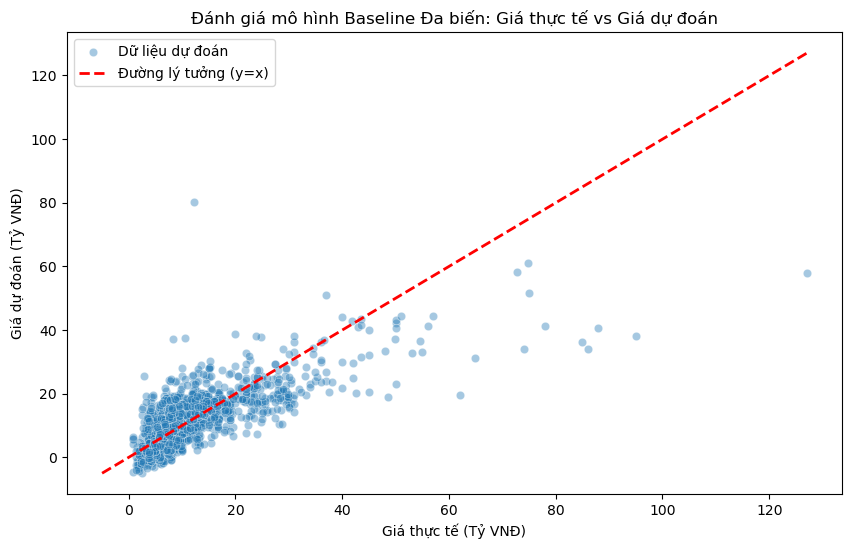

In [26]:
plt.figure(figsize=(10, 6))

# Vẽ điểm dữ liệu (Giá thực tế vs Giá dự đoán)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4, label='Dữ liệu dự đoán')

# Vẽ đường chéo y = x (Đường dự đoán hoàn hảo, tại đây y_pred == y_test)
max_val = max(y_test.max(), y_pred.max())
min_val = min(y_test.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linewidth=2, linestyle='--', label='Đường lý tưởng (y=x)')

plt.title("Đánh giá mô hình Baseline Đa biến: Giá thực tế vs Giá dự đoán")
plt.xlabel("Giá thực tế (Tỷ VNĐ)")
plt.ylabel("Giá dự đoán (Tỷ VNĐ)")
plt.legend()
plt.show()

## 4. Đánh giá hiệu suất mô hình Baseline

Dựa trên kết quả thực thi và trực quan hóa biểu đồ (Giá thực tế vs Giá dự đoán), nhóm rút ra các nhận xét quan trọng sau về mô hình Baseline:

* **Đánh giá các hệ số hồi quy:** 
    - **Số tầng** đóng vai trò lớn nhất trong việc gia tăng giá trị (tăng thêm ~2.81 tỷ VND cho mỗi tầng).
    - **Diện tích đất** và **số phòng tắm** có tác động thuận chiều, làm tăng giá trị căn nhà một cách hợp lý.
    - Đáng chú ý là **số phòng ngủ** mang hệ số âm (-0.6064). Điều này phản ánh thực tế rằng, nếu chia nhỏ cùng một diện tích thành quá nhiều phòng ngủ sẽ làm thu hẹp không gian mỗi phòng, gây cảm giác chật chội và làm giảm giá trị tổng thể.
* **Độ khớp của mô hình (R-squared ≈ 0.542):** Bằng cách sử dụng 4 đặc trưng cấu trúc vật lý cơ bản, mô hình giải thích được **54.2%** sự biến động của giá nhà. Mặc dù đã nắm bắt được một phần xu hướng, nhưng gần 46% phương sai vẫn chưa thể giải thích, cho thấy các biến số hiện tại chưa đủ sức bao quát toàn bộ thị trường.
* **Sai số dự báo (MAE ≈ 4.42 tỷ, RMSE ≈ 6.73 tỷ):** 
    - Sai số tuyệt đối trung bình (MAE) ở mức **4.42 tỷ VNĐ**, một mức chênh lệch khá lớn so với mặt bằng giá trị chung của các căn nhà.
    - RMSE (6.73 tỷ) lớn hơn hẳn so với MAE cho thấy mô hình tạo ra những sai số cục bộ rất nghiêm trọng (đặc biệt ở các căn nhà có giá trị thực tế cao lớn bất thường).
* **Phân tích biểu đồ Scatter Plot:** 
    - **Hoạt động tốt ở phân khúc phổ thông:** Đối với nhóm nhà dưới 30 tỷ dự báo bám khá sát đường lý tưởng ($y=x$).
    - **Dự báo dưới tầm (Underpredict) ở phân khúc cao cấp:** Từ mốc 40 tỷ trở lên, các điểm dự báo có xu hướng chúi xuống thấp hơn rất nhiều so với đường thẳng lý tưởng. Mô hình định giá sai lệch lớn do thiếu vắng các thông tin tạo nên tính cao cấp (VD: vị trí đắc địa, mặt tiền, hay thuộc quận trung tâm).
    - **Phương sai thay đổi (Heteroscedasticity):** Sự phân tán của các điểm dữ liệu mở rộng như hình phễu về phía tay phải, vi phạm giả định đồng phương sai cốt lõi của Hồi quy Tuyến tính.

**Kết luận:** Mô hình Baseline hoàn thành vai trò tạo một mốc tham chiếu cơ sở. Việc chỉ sử dụng các đặc trưng về cấu trúc vật lý bộc lộ rõ yếu điểm khi định giá các bất động sản giá trị cao. Nhóm sẽ tiếp tục cải thiện ở các bước tiếp theo thông qua việc **biến đổi Logarit** để xử lý phân phối lệch, giảm nhiễu ngoại lai, đồng thời **bổ sung thêm đặc trưng địa lý (Quận/Huyện, Tỉnh/Thành phố)**.